# 2. Construcción de teselas batimétricas

- Se realiza la partición de las mallas batimétricas interpoladas en **teselas regulares** de tamaño fijo. 
- Para X6By5 se utilizan teselas de 68 x 68 píxeles.
- Se hace la partición de los datos en teselas para reducir la dimensionalidad de los datos de entrada

## 2.1. Pasos

- Se trabaja sobre una **malla regular base** previamente generada para el sector.
- Cada batimetría interpolada se divide en teselas de tamaño `TILE_SIZE × TILE_SIZE`.
- Para cada tesela se calcula:
  - número de celdas válidas,
  - número de `NaN`,
  - cobertura porcentual.
- Se descartan las teselas con menos del **10 % de celdas válidas**.
- Los `NaN` de las teselas aceptadas se reemplazan por **0.0**.
- Se guardan dos salidas:
  - un archivo `.npz` con el tensor `X_tiles`,
  - un archivo `.csv` con los metadatos de las teselas aceptadas.

```python
nrows, ncols = gx.shape

n_tiles_filas = nrows // TILE_SIZE
n_tiles_cols = ncols // TILE_SIZE

# Guardar índices de cada tesela completa
tiles_idx = []

for i in range(n_tiles_filas):
    for j in range(n_tiles_cols):
        r0 = i * TILE_SIZE
        r1 = r0 + TILE_SIZE
        c0 = j * TILE_SIZE
        c1 = c0 + TILE_SIZE

        tiles_idx.append({
            "tile_id": f"r{r0:04d}_c{c0:04d}",
            "i_tile": i,
            "j_tile": j,
            "row_ini": r0,
            "row_fin": r1,
            "col_ini": c0,
            "col_fin": c1
        })


df_tiles_idx = pd.DataFrame(tiles_idx)


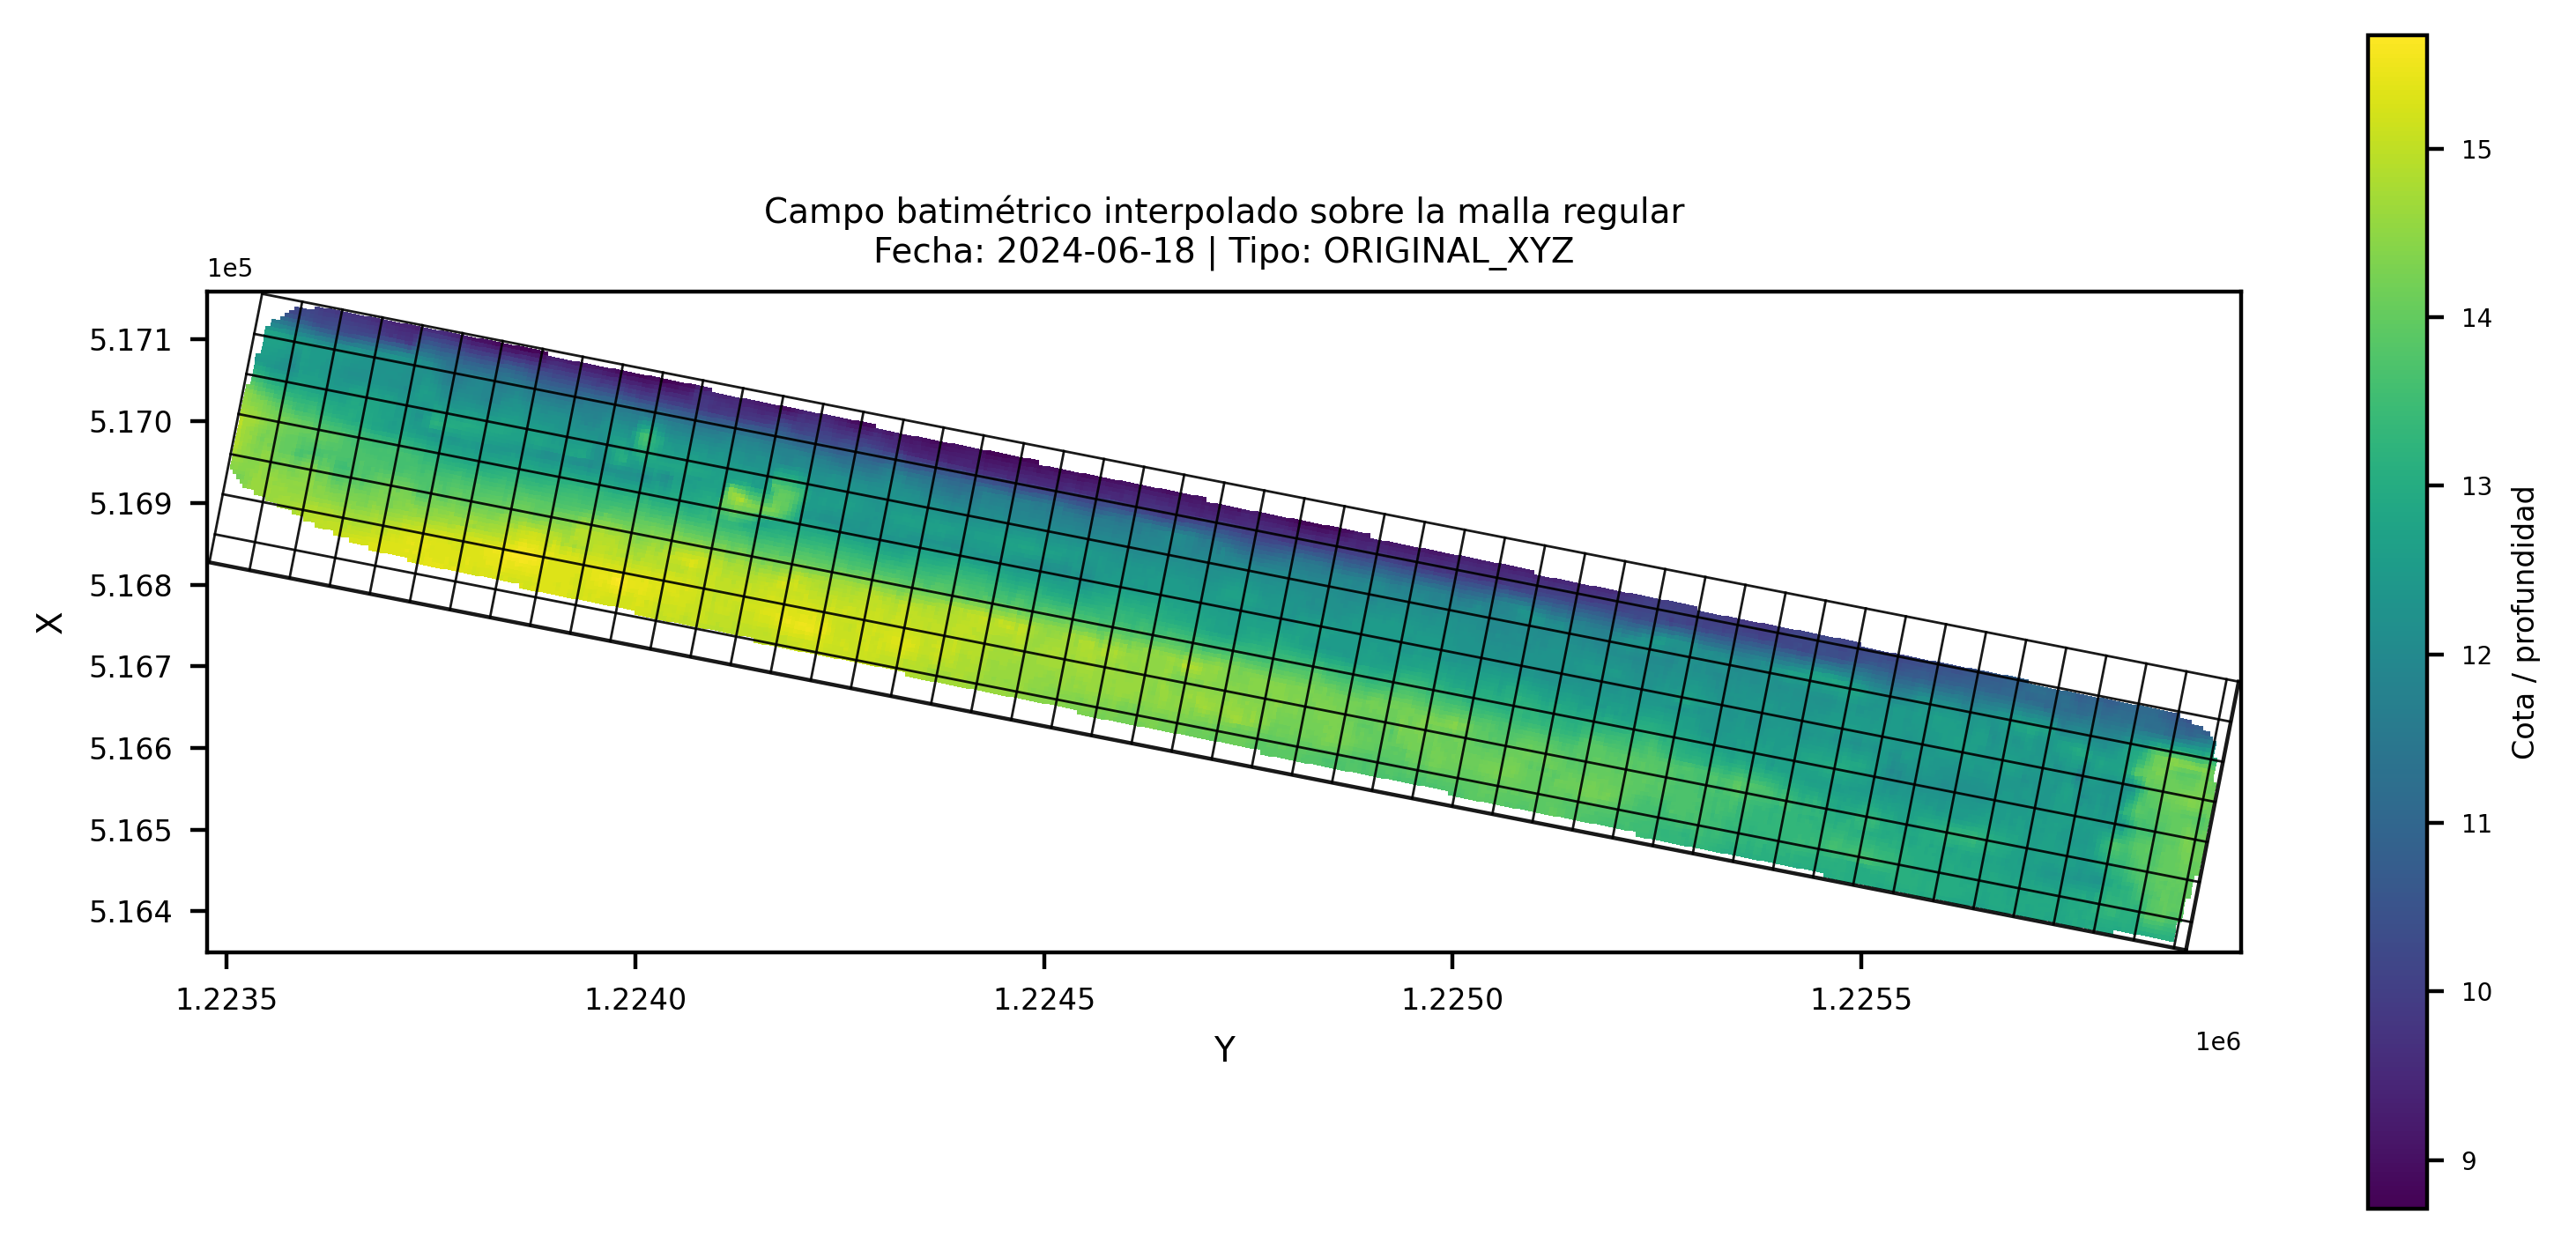